In [1]:
#===============================================================================

#       DATASCIENCE CAPSTONE PROJECT

#===============================================================================

In [2]:
#imports

import sys
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import unicodedata
import numpy as np



In [3]:
#functions to extract data
def date_time(table_cells):
    return [data_time.strip() for data_time in list(table_cells.strings)][0:2]

def booster_version(table_cells):
    out=''.join([booster_version for i,booster_version in enumerate( table_cells.strings) if i%2==0][0:-1])
    return out

def landing_status(table_cells):
    out=[i for i in table_cells.strings][0]
    return out


def get_mass(table_cells):
    mass=unicodedata.normalize("NFKD", table_cells.text).strip()
    if mass:
        mass.find("kg")
        new_mass=mass[0:mass.find("kg")+2]
    else:
        new_mass=0
    return new_mass


def extract_column_from_header(row):
    if (row.br):
        row.br.extract()
    if row.a:
        row.a.extract()
    if row.sup:
        row.sup.extract()

    colunm_name = ' '.join(row.contents)

    # Filter the digit and empty names
    if not(colunm_name.strip().isdigit()):
        colunm_name = colunm_name.strip()
        return colunm_name


In [4]:
#source
static_url="https://en.wikipedia.org/w/index.php?title=List_of_Falcon_9_and_Falcon_Heavy_launches&oldid=1027686922"

headers={
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/91.0.4472.124 Safari/537.36"
}

In [5]:
# Request the Falcon9 Launch Wiki page
response=requests.get(static_url, headers=headers)

# Check status
print(response.status_code)

200


In [6]:
soup = BeautifulSoup(response.text, "html.parser")
print(soup.prettify()[0:200])

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-pag


In [7]:
#DATA extraction

# Find all tables on the page
tables=soup.find_all("table", "wikitable")

print("Number of tables found:", len(tables))

first_table=tables[0]

header_row=first_table.find("tr")

header_cells=header_row.find_all("th")

# Use helper function to clean names
column_names=[extract_column_from_header(cell) for cell in header_cells]

print("Column names:", column_names)


Number of tables found: 13
Column names: ['Flight No.', 'Date and time ( )', '', 'Launch site', 'Payload', 'Payload mass', 'Orbit', 'Customer', 'Launch outcome', '']


In [8]:
#extract data from 3rd table
target_table=tables[2]
print(column_names)

for th in target_table.find_all("th"):
    name=extract_column_from_header(th)
    # Append only non-empty names
    if name is not None and len(name)>0:
        column_names.append(name)

print("Extracted column names:", column_names)

['Flight No.', 'Date and time ( )', '', 'Launch site', 'Payload', 'Payload mass', 'Orbit', 'Customer', 'Launch outcome', '']
Extracted column names: ['Flight No.', 'Date and time ( )', '', 'Launch site', 'Payload', 'Payload mass', 'Orbit', 'Customer', 'Launch outcome', '', 'Flight No.', 'Date and time ( )', 'Launch site', 'Payload', 'Payload mass', 'Orbit', 'Customer', 'Launch outcome']


In [9]:
#Create a dataframe from HTML table
launch_dict= dict.fromkeys(column_names)

# Remove an irrelvant column
del launch_dict['Date and time ( )']

# Let's initial the launch_dict with each value to be an empty list
launch_dict['Flight No.'] = []
launch_dict['Launch site'] = []
launch_dict['Payload'] = []
launch_dict['Payload mass'] = []
launch_dict['Orbit'] = []
launch_dict['Customer'] = []
launch_dict['Launch outcome'] = []
# Added some new columns
launch_dict['Version Booster']=[]
launch_dict['Booster landing']=[]
launch_dict['Date']=[]
launch_dict['Time']=[]

In [10]:
extracted_row=0
#Extract each table
for table_number,table in enumerate(soup.find_all('table',"wikitable plainrowheaders collapsible")):
   # get table row
    for rows in table.find_all("tr"):
        #check to see if first table heading is as number corresponding to launch a number
        if rows.th:
            if rows.th.string:
                flight_number=rows.th.string.strip()
                flag=flight_number.isdigit()
        else:
            flag=False
        row=rows.find_all('td')

        if flag:
            extracted_row+=1
            datatimelist=date_time(row[0])

            date=datatimelist[0].strip(',')
            launch_dict['Date'].append(date)

            time=datatimelist[1]
            launch_dict['Time'].append(time)

            bv=booster_version(row[1])
            if not(bv):
                bv=row[1].a.string if row[1].a else None
            # print(bv)
            launch_dict['Version Booster'].append(bv)

            launch_site=row[2].a.string if row[2].a else None
            launch_dict['Launch site'].append(launch_site)

            payload=row[3].a.string if row[3].a else None
            launch_dict['Payload'].append(payload)

            payload_mass=get_mass(row[4])
            launch_dict['Payload mass'].append(payload_mass)

            orbit=row[5].a.string if row[5].a else None
            launch_dict['Orbit'].append(orbit)

            customer=row[6].a.string if row[6].a else None
            launch_dict['Customer'].append(customer)

            launch_outcome=list(row[7].strings)[0] if row[7] else None
            launch_dict['Launch outcome'].append(launch_outcome)

            booster_landing=landing_status(row[8]) if row[8] else None
            launch_dict['Booster landing'].append(booster_landing)

            launch_dict['Flight No.'].append(flight_number)


In [11]:
df= pd.DataFrame({ key:pd.Series(value) for key, value in launch_dict.items()})

df.head()
df.to_csv('spacex_web_scraped.csv', index=False)

### Data Wrangling from SpaceX API

In [12]:
df.isnull().sum() #calculate the missing values count


,0
Flight No.,0
,121
Launch site,0
Payload,0
Payload mass,0
Orbit,0
Customer,2
Launch outcome,0
Version Booster,0
Booster landing,0


In [13]:
df.drop(df.columns[1], axis=1, inplace=True)
df

,Flight No.,Launch site,Payload,Payload mass,Orbit,Customer,Launch outcome,Version Booster,Booster landing,Date,Time
0,1,CCAFS,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success\n,F9 v1.07B0003.18,Failure,4 June 2010,18:45
1,2,CCAFS,Dragon,0,LEO,NASA,Success,F9 v1.07B0004.18,Failure,8 December 2010,15:43
2,3,CCAFS,Dragon,525 kg,LEO,NASA,Success,F9 v1.07B0005.18,No attempt\n,22 May 2012,07:44
3,4,CCAFS,SpaceX CRS-1,"4,700 kg",LEO,NASA,Success\n,F9 v1.07B0006.18,No attempt,8 October 2012,00:35
4,5,CCAFS,SpaceX CRS-2,"4,877 kg",LEO,NASA,Success\n,F9 v1.07B0007.18,No attempt\n,1 March 2013,15:10
...,...,...,...,...,...,...,...,...,...,...,...
116,117,CCSFS,Starlink,"15,600 kg",LEO,SpaceX,Success\n,F9 B5B1051.10657,Success,9 May 2021,06:42
117,118,KSC,Starlink,"~14,000 kg",LEO,SpaceX,Success\n,F9 B5B1058.8660,Success,15 May 2021,22:56
118,119,CCSFS,Starlink,"15,600 kg",LEO,SpaceX,Success\n,F9 B5B1063.2665,Success,26 May 2021,18:59
119,120,KSC,SpaceX CRS-22,"3,328 kg",LEO,NASA,Success\n,F9 B5B1067.1668,Success,3 June 2021,17:29


True Ocean means the mission outcome was successfully landed to a specific region of the ocean while False Ocean means the mission outcome was unsuccessfully landed to a specific region of the ocean. True RTLS means the mission outcome was successfully landed to a ground pad False RTLS means the mission outcome was unsuccessfully landed to a ground pad.True ASDS means the mission outcome was successfully landed to a drone ship False ASDS means the mission outcome was unsuccessfully landed to a drone ship. None ASDS and None None these represent a failure to land.

In [14]:
df1=pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_1.csv")
df1.head(10)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857
5,6,2014-01-06,Falcon 9,3325.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1005,-80.577366,28.561857
6,7,2014-04-18,Falcon 9,2296.000000,ISS,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1.0,0,B1006,-80.577366,28.561857
7,8,2014-07-14,Falcon 9,1316.000000,LEO,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1.0,0,B1007,-80.577366,28.561857
8,9,2014-08-05,Falcon 9,4535.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1008,-80.577366,28.561857
9,10,2014-09-07,Falcon 9,4428.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1011,-80.577366,28.561857


In [15]:
#create a set of outcomes where the second stage did not land successfully:
landing_outcomes = df1['Outcome'].value_counts()

for i,outcome in enumerate(landing_outcomes.keys()):
    print(i,outcome)

bad_outcomes=set(landing_outcomes.keys()[[1,3,5,6,7]])
print('The set of bad outcomes')
bad_outcomes

0 True ASDS
1 None None
2 True RTLS
3 False ASDS
4 True Ocean
5 False Ocean
6 None ASDS
7 False RTLS
The set of bad outcomes


{'False ASDS', 'False Ocean', 'False RTLS', 'None ASDS', 'None None'}

In [16]:
# landing_class = 0 if bad_outcome
# landing_class = 1 otherwise
landing_class=df1['Outcome'].apply(lambda x: 0 if x in bad_outcomes else 1)
#Assigning another column 'Class' to df1
df['Class']=landing_class

#Determine the success rate using mean()
df['Class'].mean()*100
#It is 66.6% of the time a safer launch


np.float64(66.66666666666666)

## **EXPLORATORY DATA ANALYSIS USING SQL**

In [17]:
from sqlalchemy import create_engine
import pandas as pd
import sqlite3

#creating connection

con = sqlite3.connect("my_data1.db")
cur = con.cursor()

In [18]:

engine = create_engine('sqlite:///mydatabase.db')

conn = sqlite3.connect('mydatabase.db')

df.to_sql("SPACEXTBL", conn, if_exists='replace', index=False, method="multi")


121

In [19]:
df1.to_sql("SPACEXTBL", conn, if_exists='replace', index=False, method="multi")
cur = conn.cursor()
cur.execute("DROP TABLE IF EXISTS SPACEXTABLE;")
cur.execute("CREATE TABLE SPACEXTABLE AS SELECT * FROM SPACEXTBL WHERE Date IS NOT NULL;")
conn.commit() # Commit the changes to the database
print("Table SPACEXTABLE created successfully, filtering out null dates.")

Table SPACEXTABLE created successfully, filtering out null dates.


In [20]:
cur.execute("select * from SPACEXTABLE limit 5")
rows = cur.fetchall()
for row in rows:
    print(row)
conn.commit()

(1, '2010-06-04', 'Falcon 9', 6104.959411764706, 'LEO', 'CCAFS SLC 40', 'None None', 1, 0, 0, 0, None, 1.0, 0, 'B0003', -80.577366, 28.5618571)
(2, '2012-05-22', 'Falcon 9', 525.0, 'LEO', 'CCAFS SLC 40', 'None None', 1, 0, 0, 0, None, 1.0, 0, 'B0005', -80.577366, 28.5618571)
(3, '2013-03-01', 'Falcon 9', 677.0, 'ISS', 'CCAFS SLC 40', 'None None', 1, 0, 0, 0, None, 1.0, 0, 'B0007', -80.577366, 28.5618571)
(4, '2013-09-29', 'Falcon 9', 500.0, 'PO', 'VAFB SLC 4E', 'False Ocean', 1, 0, 0, 0, None, 1.0, 0, 'B1003', -120.610829, 34.632093)
(5, '2013-12-03', 'Falcon 9', 3170.0, 'GTO', 'CCAFS SLC 40', 'None None', 1, 0, 0, 0, None, 1.0, 0, 'B1004', -80.577366, 28.5618571)


In [21]:
cur.execute("""SELECT LandingPad, COUNT(Outcome) AS NumberOfSuccesses FROM SPACEXTABLE WHERE Outcome IN ('True ASDS', 'True RTLS', 'True Ocean') GROUP BY LandingPad;""")

success_by_landing_pad = cur.fetchall()

print("Number of successful landings grouped by LandingPad:")
for row in success_by_landing_pad:
    print(f"LandingPad: {row[0]}, Successes: {row[1]}")

Number of successful landings grouped by LandingPad:
LandingPad: None, Successes: 5
LandingPad: 5e9e3032383ecb267a34e7c7, Successes: 12
LandingPad: 5e9e3032383ecb554034e7c9, Successes: 2
LandingPad: 5e9e3032383ecb6bb234e7ca, Successes: 30
LandingPad: 5e9e3033383ecbb9e534e7cc, Successes: 11


## DATA VISUALIZATION

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt


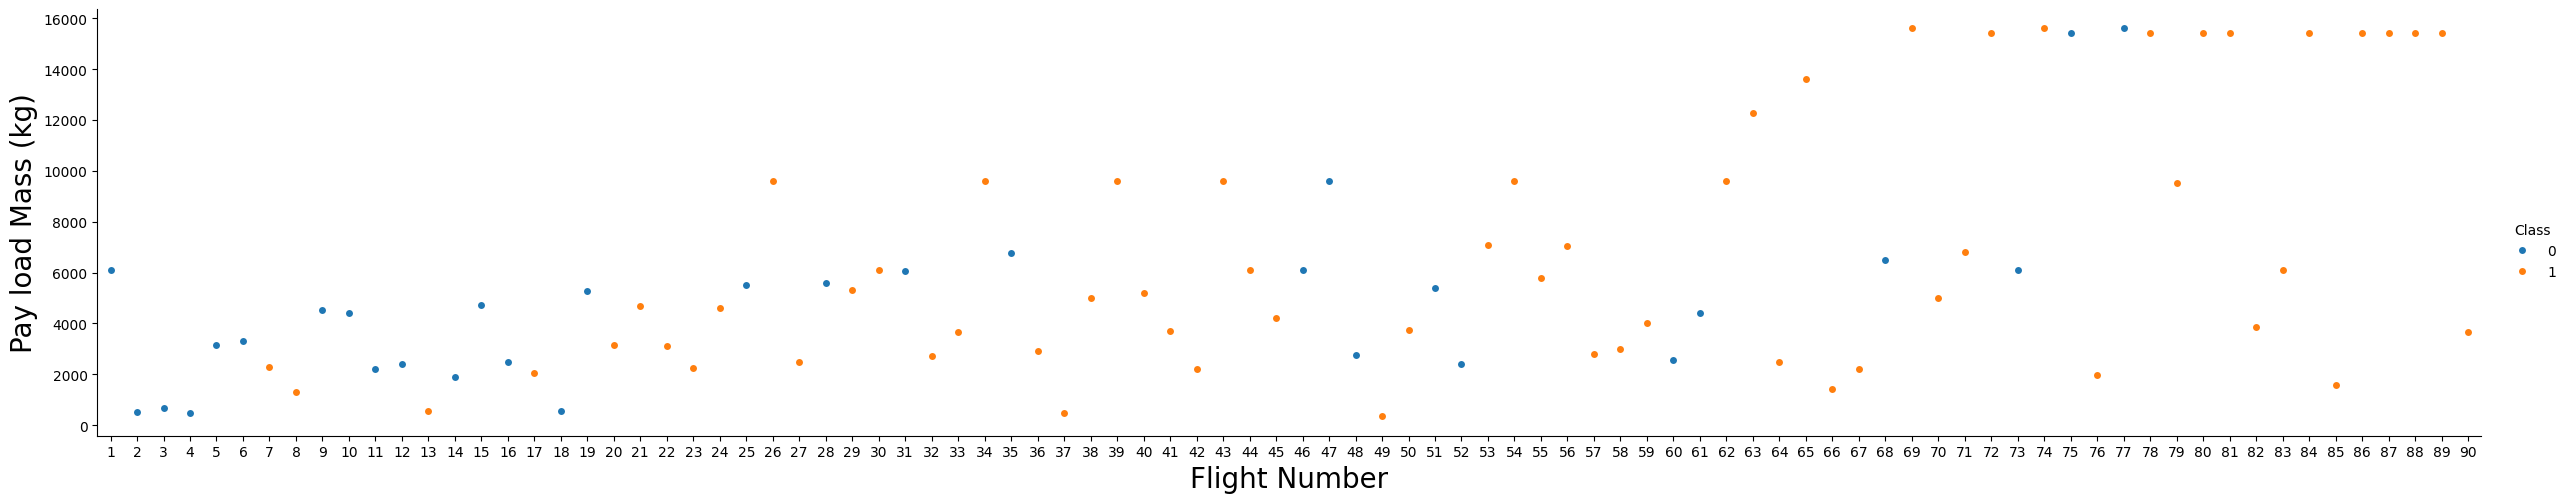

In [23]:
df1['Class'] = landing_class
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df1, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

### **Inference:**
__From the plot, we can infer a clear trend: as the FlightNumber increases, indicating later missions, there is a noticeable increase in the number of successful landings (represented by orange dots, where 'Class' is 1). In the earlier flights (lower FlightNumber values), there are more unsuccessful landings (blue dots, where 'Class' is 0), often associated with lower PayloadMass. As SpaceX gained experience and refined its technology, it was able to successfully land boosters with increasingly heavier PayloadMass values.__

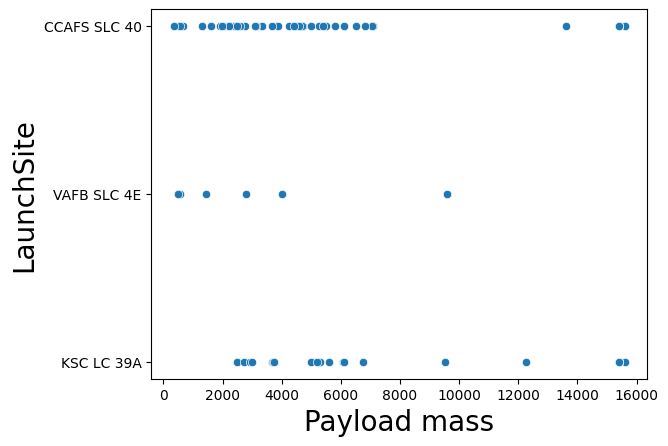

In [24]:

sns.scatterplot(x='PayloadMass', y='LaunchSite',data=df1)
plt.xlabel("Payload mass",fontsize=20)
plt.ylabel("LaunchSite",fontsize=20)
plt.show()

**CCAFS SLC 40** is the most frequently used launch site, handling a wide spectrum of payload masses, including both light and very heavy payloads.


**KSC LC 39A **also serves a substantial number of launches, particularly for heavier payloads, showing a similar versatility to CCAFS SLC 40 in terms of the range of masses handled.

**VAFB SLC 4E** appears to be used for fewer launches, predominantly for payloads in the lower to mid-range of masses, with fewer instances of extremely heavy payloads compared to the other two sites.

__The plot suggests that the CCAFS SLC 40 and KSC LC 39A sites are equipped to handle a broader and heavier range of payloads, indicating their strategic importance for diverse mission requirements.__

   Orbit     Class
0  ES-L1  1.000000
1    GEO  1.000000
2    GTO  0.518519
3    HEO  1.000000
4    ISS  0.619048


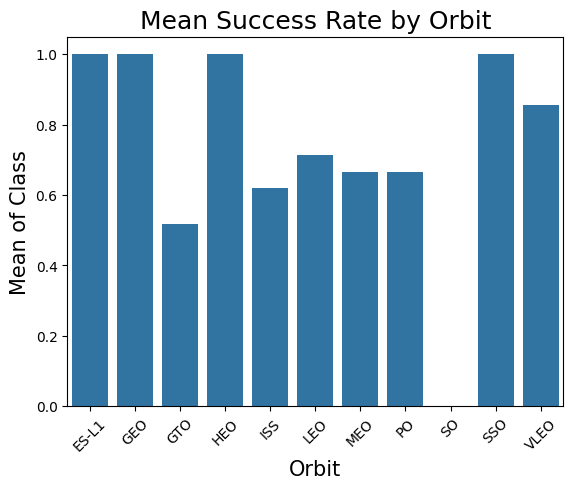

In [25]:

orbit_class_mean = df1.groupby('Orbit')['Class'].mean().reset_index()
print(orbit_class_mean.head())  # snapshot

sns.barplot(x='Orbit', y='Class', data=orbit_class_mean)

plt.xlabel("Orbit", fontsize=15)
plt.ylabel("Mean of Class", fontsize=15)
plt.title("Mean Success Rate by Orbit", fontsize=18)
plt.xticks(rotation=45)
plt.show()

In [26]:
#converting the date to year
year=[]
def Extract_year():
    for i in df1["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()
df1['Date'] = year
df1.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


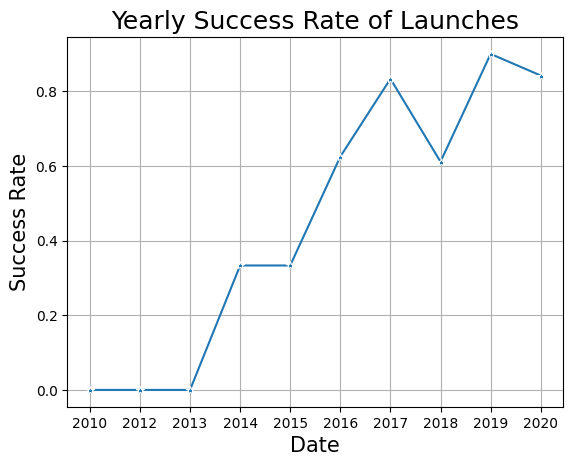

In [27]:
#Visualizing the success rate
yearly_success = df1.groupby('Date')['Class'].mean().reset_index()
sns.lineplot(x='Date', y='Class', data=yearly_success, marker='*')
plt.xlabel("Date", fontsize=15)
plt.ylabel("Success Rate", fontsize=15)
plt.title("Yearly Success Rate of Launches", fontsize=18)
plt.grid(True)
plt.show()


#you can observe that the sucess rate since 2013 kept increasing till 2020


## **FEATURE ENGINEERING**

In [28]:
features = df1[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


In [29]:
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
features_one_hot = features_one_hot.astype('float64')
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
features_one_hot.to_csv('FeatureEngg_one_hot.csv', index=False)

In [31]:
import folium
from folium.plugins import MarkerCluster
from folium.plugins import MousePosition
from folium.features import DivIcon

In [32]:
folium.Map(location=[28.563, -80.576], zoom_start=5)

In [33]:
spacex_df=df1[['LaunchSite', 'Latitude', 'Longitude', 'Class']]
launch_sites_df=spacex_df.groupby(['LaunchSite'], as_index=False).first()
launch_sites_df=launch_sites_df[['LaunchSite', 'Latitude', 'Longitude']]
launch_sites_df

,LaunchSite,Latitude,Longitude
0,CCAFS SLC 40,28.561857,-80.577366
1,KSC LC 39A,28.608058,-80.603956
2,VAFB SLC 4E,34.632093,-120.610829


Above coordinates are just plain numbers that can not give you any intuitive insights about where are those launch sites.

In [34]:
df1.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [35]:
nasa_coordinate=[29.559684888503615, -95.0830971930759]
site_map=folium.Map(location=nasa_coordinate, zoom_start=5)
marker_cluster=MarkerCluster().add_to(site_map)
for index, row in df1.iterrows():
    # Success = green, Failure = red
    outcome_color = 'green' if row['Class'] == 1 else 'red'

    folium.Marker(
        location=[row['Latitude'], row['Longitude']],   # lat/long columns
        popup=f"Site: {row['LaunchSite']}<br>Outcome: {row['Outcome']}",
        icon=folium.Icon(color=outcome_color, icon='rocket')
    ).add_to(marker_cluster)


site_map

In [36]:
df1['marker_color']=df1['Class'].apply(lambda x: 'green' if x == 1 else 'red')

# Quick check
df1[['Class', 'marker_color']].head()

,Class,marker_color
0,0,red
1,0,red
2,0,red
3,0,red
4,0,red


In [37]:
for index, record in spacex_df.iterrows():
    # Determine the color of the marker based on the 'Class' (success or failure)
    color = 'green' if record['Class'] == 1 else 'red'

    # Create a folium.Marker object for each record
    marker = folium.Marker(
        location=[record['Latitude'], record['Longitude']],
        popup=f"Launch Site: {record['LaunchSite']}<br>Class: {record['Class']}", # Popup information
        icon=folium.Icon(color=color, icon='rocket')
    )
    # Add the newly created marker to the marker_cluster
    marker_cluster.add_child(marker)

# Display the map with all the markers
site_map

### FOLIUM INSIGHTS

**Geographical Concentration:** The map clearly shows the geographical locations of the three primary launch sites: CCAFS SLC 40, KSC LC 39A (both in Florida, close to each other), and VAFB SLC 4E (in California).


**Success and Failure by Site**: By observing the distribution of green (success) and red (failure) rocket icons clustered at each launch site, we can get a visual understanding of the success rates. For instance, a site with a higher density of green markers indicates a better success record.


**Launch Activity:** The number of markers at each location provides a visual representation of the launch frequency from that site.


# **PREDICTIVE ANALYSIS**

In [38]:
           # Testing for
                     # Logistic Regression
                     # Support Vector Machine
                     # Decision Tree Classifier
                     # K-nearest Neighbour


In [39]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [40]:
#Confusion matrix plot

def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix');
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed'])
    plt.show()

In [41]:
URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
data1 = pd.read_csv(URL1)
data1.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [42]:
URL2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
data2=pd.read_csv(URL2)
data2.head()

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [43]:
# data1=df1 and data2=df

Class_Outcome=data1['Class'].to_numpy()
Class_Outcome

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [44]:
#StandardScaler()
scaler = preprocessing.StandardScaler()

# Train Test split (80-20) BEFORE scaling
x_train_raw, x_test_raw, y_train, y_test = train_test_split(data2, Class_Outcome, test_size=0.2, random_state=2, stratify=Class_Outcome)

# Scale the data using the scaler fitted on x_train_raw
x_train = scaler.fit_transform(x_train_raw)
x_test = scaler.transform(x_test_raw) # Only transform, do not fit again

print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

(72, 83) (72,)
(18, 83) (18,)


In [45]:
#===============================================================================
#         LOGISTIC REGRESSION
#===============================================================================

parameters={'C':[0.01,0.1,1],'penalty':['l2'],'solver':['lbfgs']}
parameters={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}

# Logistic Regression object - Increased max_iter for better convergence
lr=LogisticRegression(max_iter=1000) # Increased max_iter from default (100)

# GridSearchCV object
logreg_cv = GridSearchCV(lr, parameters, cv=10)

# Fit the GridSearchCV object to the training data
logreg_cv.fit(x_train, y_train)

GridSearchCV(cv=10, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1], 'penalty': ['l2'],
                         'solver': ['lbfgs']})

In [46]:
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)
test_accuracy = logreg_cv.score(x_test, y_test)
print("Test set accuracy:", test_accuracy)

tuned hpyerparameters :(best parameters)  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.85
Test set accuracy: 0.8333333333333334


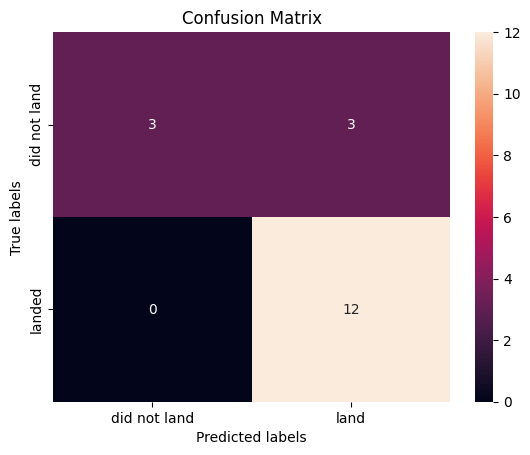

In [47]:
#calling confusion matrix
yhat=logreg_cv.predict(x_test)
plot_confusion_matrix(y_test,yhat)

from this, the True positive=12, True negative=3, False negative=0, False positive=3;;

In [48]:
#===============================================================================
#                          SVM
#===============================================================================

parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}

#SVM object
svm = SVC()

#GridSearchCV object
svm_cv=GridSearchCV(svm,parameters,cv=10)

#fit
svm_cv.fit(x_train,y_train)



GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': array([1.00000000e-03, 3.16227766e-02, 1.00000000e+00, 3.16227766e+01,
       1.00000000e+03]),
                         'gamma': array([1.00000000e-03, 3.16227766e-02, 1.00000000e+00, 3.16227766e+01,
       1.00000000e+03]),
                         'kernel': ('linear', 'rbf', 'poly', 'rbf', 'sigmoid')})

In [49]:

print("tuned hyperparameters :(best parameters)", svm_cv.best_params_)
print("accuracy :", svm_cv.best_score_)

#Test accuracy
test_accuracy = svm_cv.score(x_test,y_test)
print("Test set accuracy:", test_accuracy)

tuned hyperparameters :(best parameters) {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
accuracy : 0.8642857142857144
Test set accuracy: 0.8333333333333334


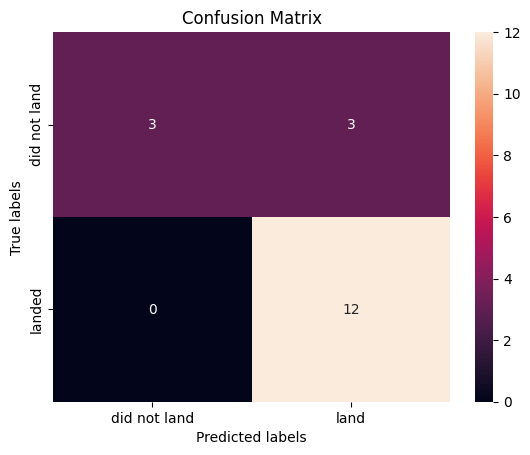

In [50]:
yhat_svm=svm_cv.predict(x_test)
plot_confusion_matrix(y_test,yhat_svm)

In [51]:
#===============================================================================
#         DECISION TREE CLASSIFIER
#===============================================================================

parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['auto', 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

# tree object
tree = DecisionTreeClassifier()

# gridsearch object
tree_cv = GridSearchCV(tree,parameters,cv=10)

# fit
tree_cv.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
3240 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3240 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/u

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 8, 10, 12, 14, 16, 18],
                         'max_features': ['auto', 'sqrt'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [52]:
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'splitter': 'best'}
accuracy : 0.9053571428571429


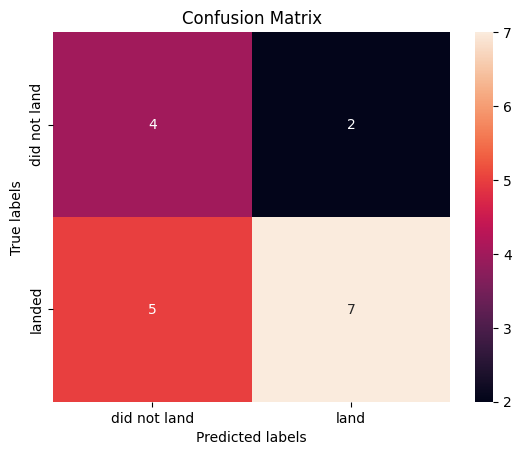

In [53]:
#Confusion matrix

yhat_tree=tree_cv.predict(x_test)
plot_confusion_matrix(y_test,yhat_tree)

In [54]:
 #==============================================================================
 #         K-Neighbors Classifier
 #==============================================================================

parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN=KNeighborsClassifier()

# gridsearch object
knn_cv=GridSearchCV(KNN, parameters, cv=10)

# fit
knn_cv.fit(x_train, y_train)


GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'p': [1, 2]})

In [55]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

#Test score
test_accuracy=knn_cv.score(x_test, y_test)
print("Test set accuracy:",test_accuracy)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 4, 'p': 1}
accuracy : 0.8642857142857142
Test set accuracy: 0.7777777777777778


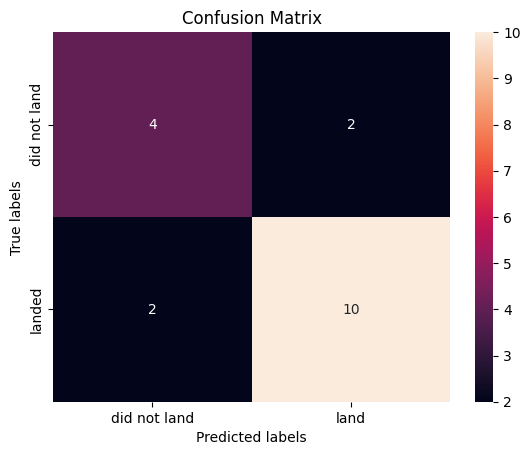

In [56]:
#Confusion matrix

yhat_knn=knn_cv.predict(x_test)
plot_confusion_matrix(y_test,yhat_knn)

In [57]:
# collect test accuracies
acc_logreg=logreg_cv.score(x_test, y_test)
acc_svm=svm_cv.score(x_test, y_test)
acc_tree=tree_cv.score(x_test, y_test)
acc_knn=knn_cv.score(x_test, y_test)

print("Logistic Regression:", acc_logreg)
print("SVM:", acc_svm)
print("Decision Tree:", acc_tree)
print("KNN:", acc_knn)

methods = {
    "Logistic Regression": acc_logreg,
    "SVM": acc_svm,
    "Decision Tree": acc_tree,
    "KNN": acc_knn
}

best_score = max(methods.values())
best_methods = [m for m, s in methods.items() if s == best_score]

print("Best performing method(s):", best_methods)


Logistic Regression: 0.8333333333333334
SVM: 0.8333333333333334
Decision Tree: 0.6111111111111112
KNN: 0.7777777777777778
Best performing method(s): ['Logistic Regression', 'SVM']
